In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import variation, skew
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import math

In [76]:
data = pd.read_csv("/content/online_vs_offline_learning_dataset.csv")
data.head()

,Learning_Mode,Subject,Study_Hours,Retention_Score,Focus_Level,Exam_Score
0,Offline,English,7.7,51,96,70
1,Offline,English,6.2,90,82,81
2,Online,English,1.2,75,66,71
3,Online,Math,6.5,80,64,77
4,Online,English,5.5,95,58,78


In [77]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Learning_Mode    1000 non-null   object 
 1   Subject          1000 non-null   object 
 2   Study_Hours      1000 non-null   float64
 3   Retention_Score  1000 non-null   int64  
 4   Focus_Level      1000 non-null   int64  
 5   Exam_Score       1000 non-null   int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 47.0+ KB


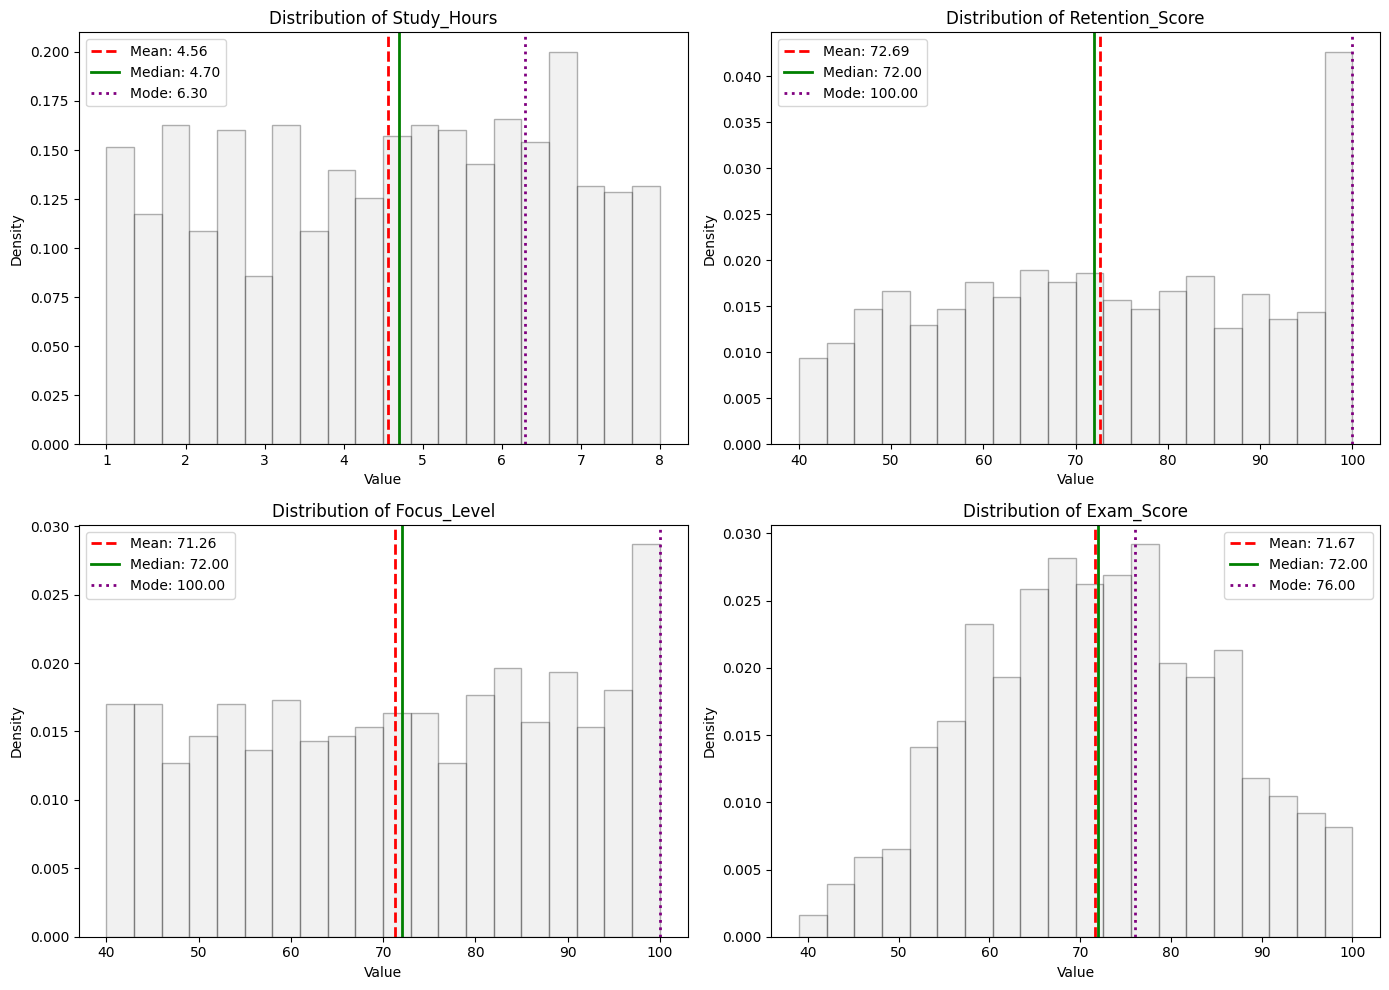

In [88]:
cols_to_plot = data.select_dtypes(include=['int64', 'float64']).columns.drop('Learning_Mode_Binary')
num_cols = len(cols_to_plot)

# 2. CALCULATE ROWS NEEDED (ASSUMING 2 COLUMNS PER ROW)
# MATH.CEIL ENSURES 5 COLS -> 3 ROWS
num_rows = math.ceil(num_cols / 2)

fig, axes = plt.subplots(nrows=num_rows, ncols=2, figsize=(14, num_rows * 5))
axes = axes.flatten()

for i, col_name in enumerate(cols_to_plot):
    col_data = data[col_name].dropna()

    mean_val = np.mean(col_data)
    median_val = np.median(col_data)
    mode_val = stats.mode(col_data, keepdims=True).mode[0]
    counts, bins, patches = axes[i].hist(col_data, bins=20, alpha=0.3,
                                         color='lightgray', edgecolor='black',
                                         density=True)

    # FREQUENCY POLYGON LOGIC
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[i].axvline(mode_val, color='purple', linestyle=':', linewidth=2, label=f'Mode: {mode_val:.2f}')

    # FORMATTING THE SUBPLOT
    axes[i].set_title(f'Distribution of {col_name}')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()
# 3. HIDE ANY EMPTY SUBPLOTS (E.G., IF YOU HAVE 5 COLS IN A 6-SLOT GRID)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

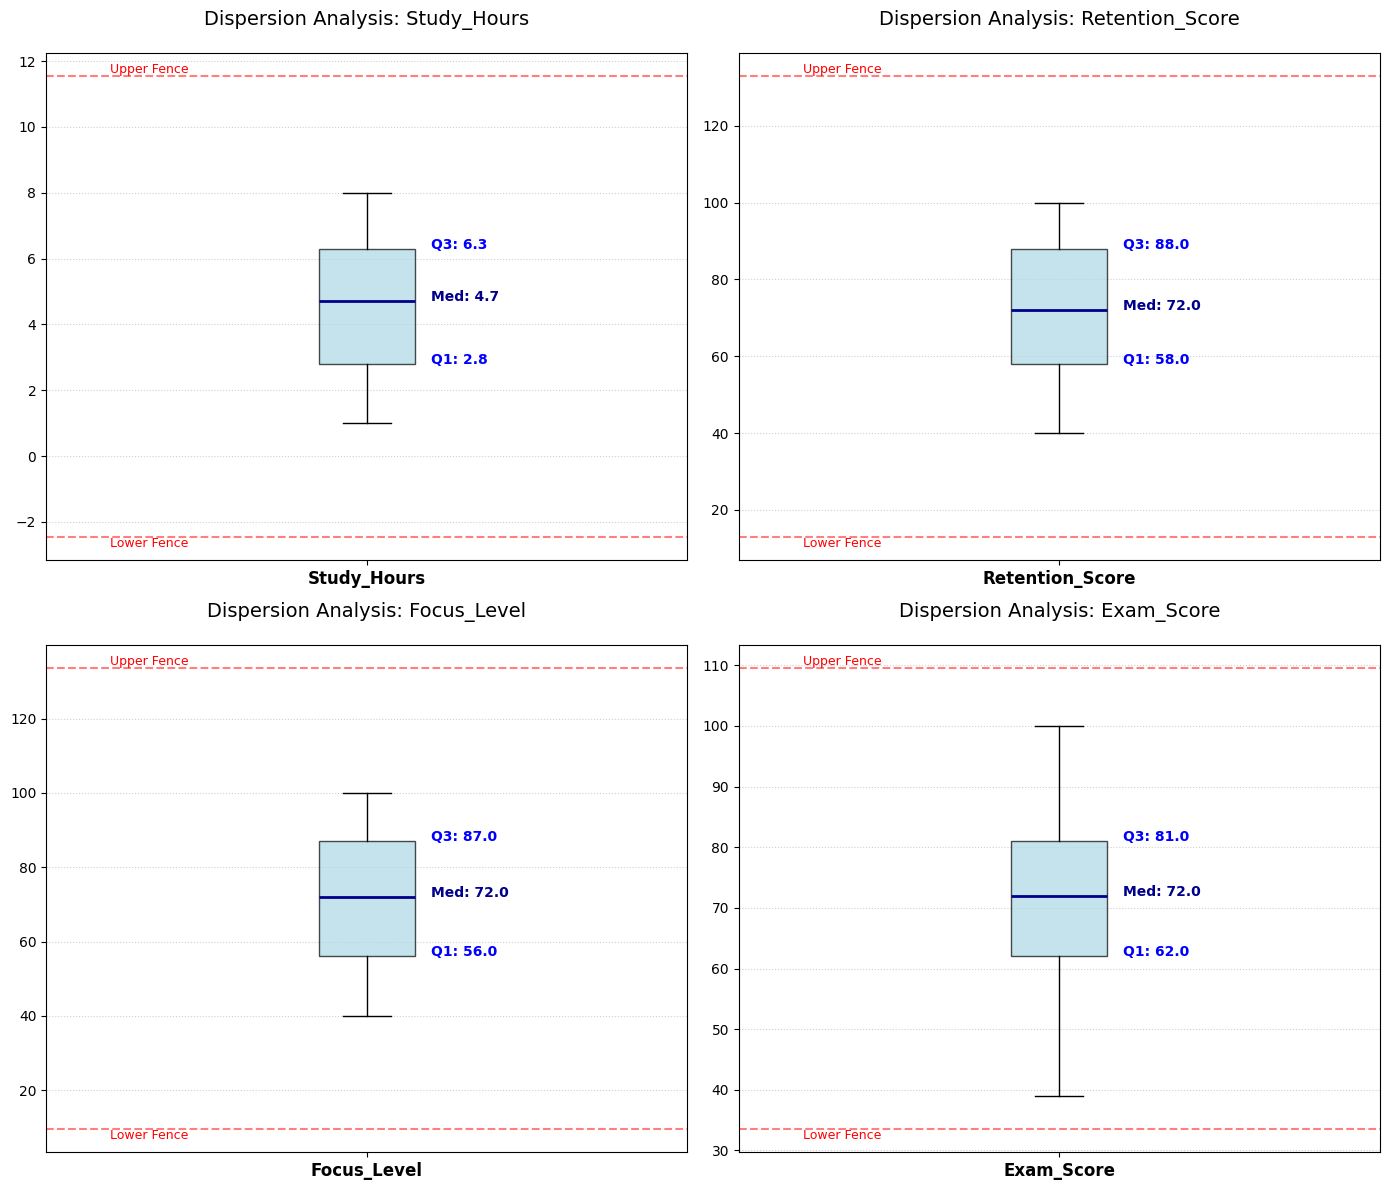

In [87]:
cols = data.select_dtypes(include=['int64', 'float64']).columns.drop('Learning_Mode_Binary')

flier_style = dict(marker='o', markerfacecolor='red', markersize=8,
                  linestyle='none', markeredgecolor='black')

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    d = data[col].dropna()

    q1, median, q3 = np.percentile(d, [25, 50, 75])
    iqr = q3 - q1

    lower_fence = q1 - (1.5 * iqr)
    upper_fence = q3 + (1.5 * iqr)

    axes[i].boxplot(d, patch_artist=True,
                    flierprops=flier_style,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='darkblue', linewidth=2))

    axes[i].text(1.1, q1, f'Q1: {q1:.1f}', color='blue', fontweight='bold')
    axes[i].text(1.1, median, f'Med: {median:.1f}', color='darkblue', fontweight='bold')
    axes[i].text(1.1, q3, f'Q3: {q3:.1f}', color='blue', fontweight='bold')

    axes[i].axhline(upper_fence, color='red', linestyle='--', alpha=0.5)
    axes[i].axhline(lower_fence, color='red', linestyle='--', alpha=0.5)

    axes[i].text(0.6, upper_fence, 'Upper Fence', color='red', fontsize=9, va='bottom')
    axes[i].text(0.6, lower_fence, 'Lower Fence', color='red', fontsize=9, va='top')

    axes[i].set_title(f'Dispersion Analysis: {col}', fontsize=14, pad=20)
    axes[i].set_xticklabels([col], fontsize=12, fontweight='bold')
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

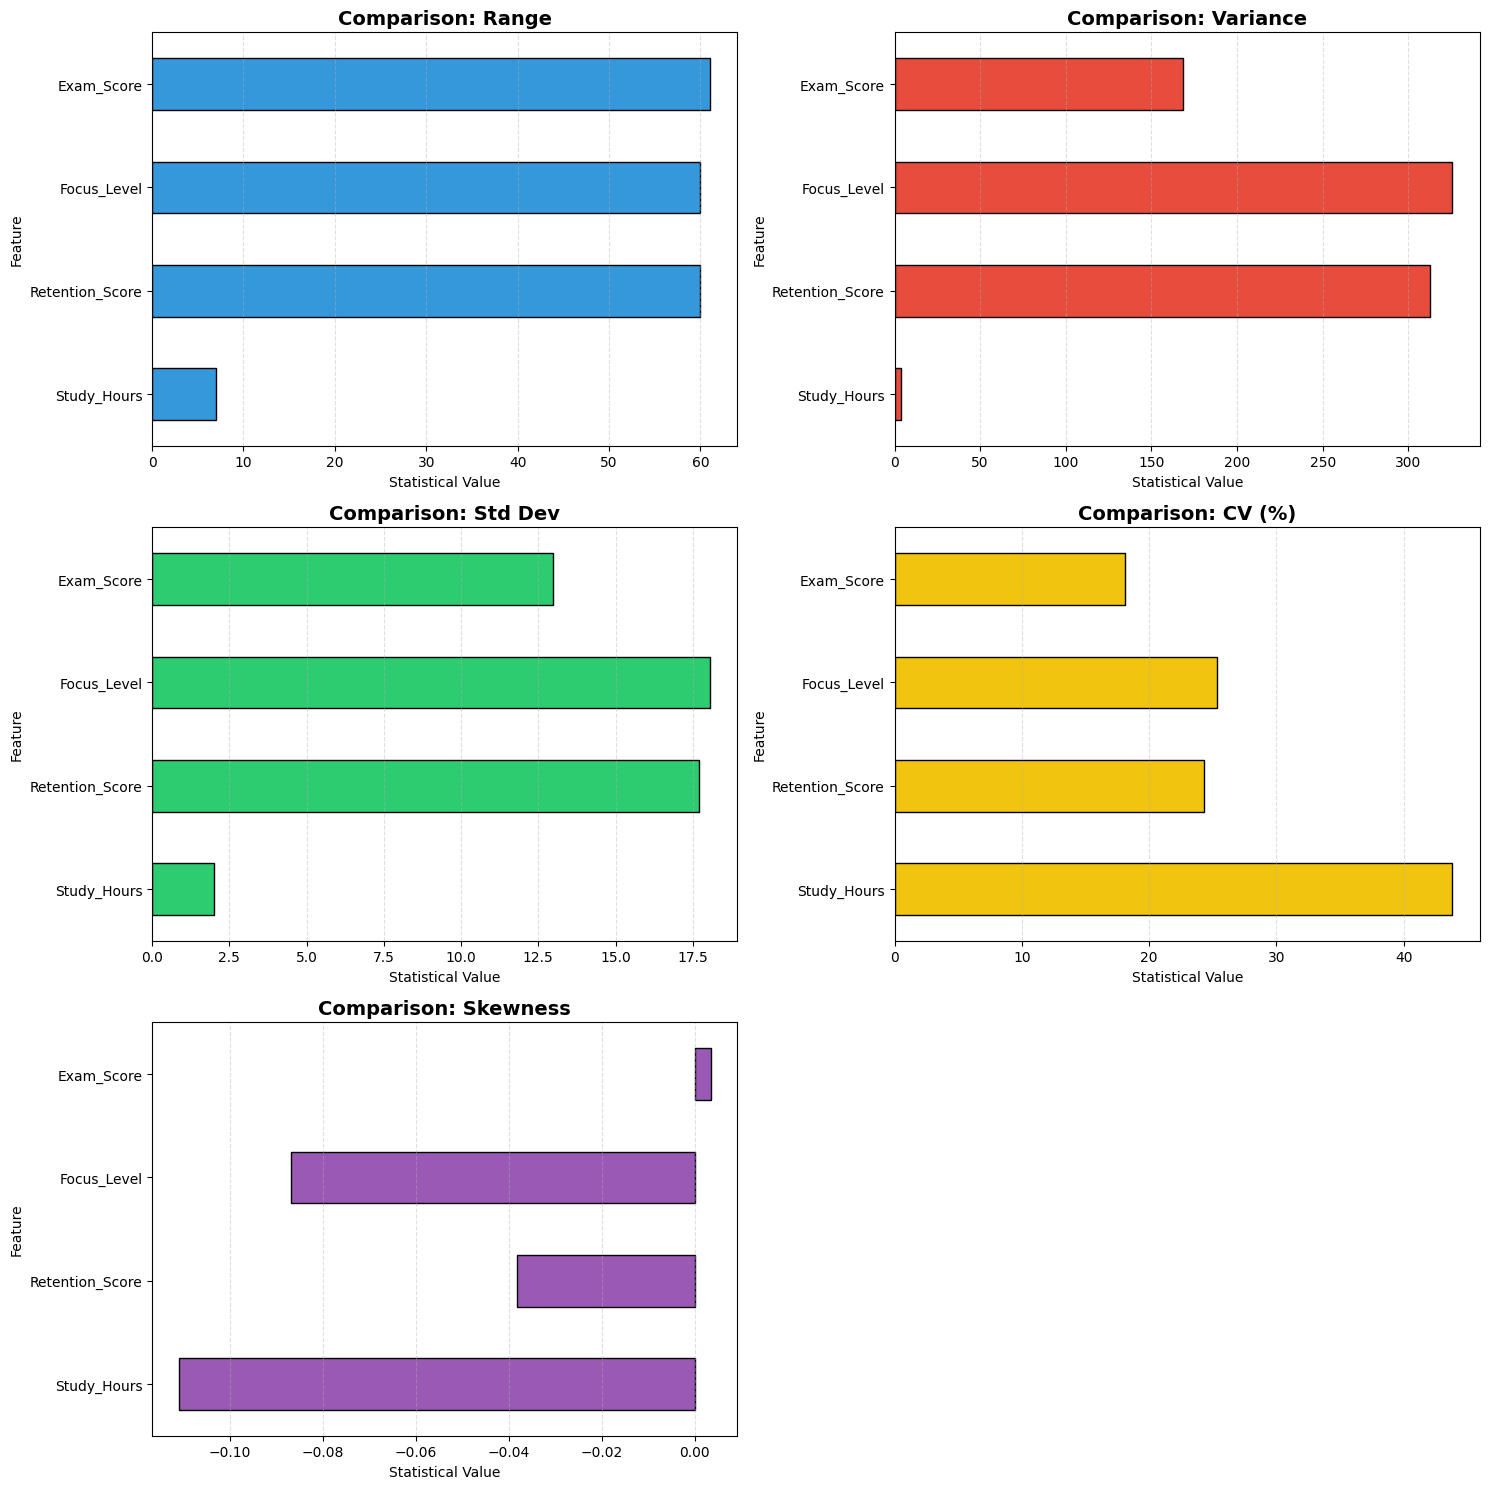

In [85]:
cols = data.select_dtypes(include=['int64', 'float64']).columns.drop('Learning_Mode_Binary')

stats_list = []
for col in cols:
    col_data = data[col].dropna()
    stats_list.append({
        'Feature': col,
        'Range': np.ptp(col_data),
        'Variance': np.var(col_data),
        'Std Dev': np.std(col_data),
        'CV (%)': variation(col_data) * 100,
        'Skewness': skew(col_data)
    })

stats_df = pd.DataFrame(stats_list).set_index('Feature')

metrics = ['Range', 'Variance', 'Std Dev', 'CV (%)', 'Skewness']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f', '#9b59b6']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    stats_df[metric].plot(kind='barh', ax=axes[i], color=colors[i], edgecolor='black')

    axes[i].set_title(f'Comparison: {metric}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Statistical Value')
    axes[i].grid(axis='x', linestyle='--', alpha=0.4)


if len(axes) > len(metrics):
    for j in range(len(metrics), len(axes)):
        axes[j].axis('off')


plt.tight_layout()
plt.show()

In [83]:
data['Learning_Mode_Binary'] = data['Learning_Mode'].map({'Online': 1, 'Offline': 0})
correlation = data[['Learning_Mode_Binary', 'Exam_Score']].corr().iloc[0, 1]

print(f"correlation coefficient (r): {correlation:.4f}")

correlation coefficient (r): -0.1126


In [89]:
df_encoded = pd.get_dummies(data, drop_first=True)

X = df_encoded.drop('Exam_Score', axis=1)
y = df_encoded['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


Mean Squared Error (MSE): 9.97
R-squared (R2): 0.94
